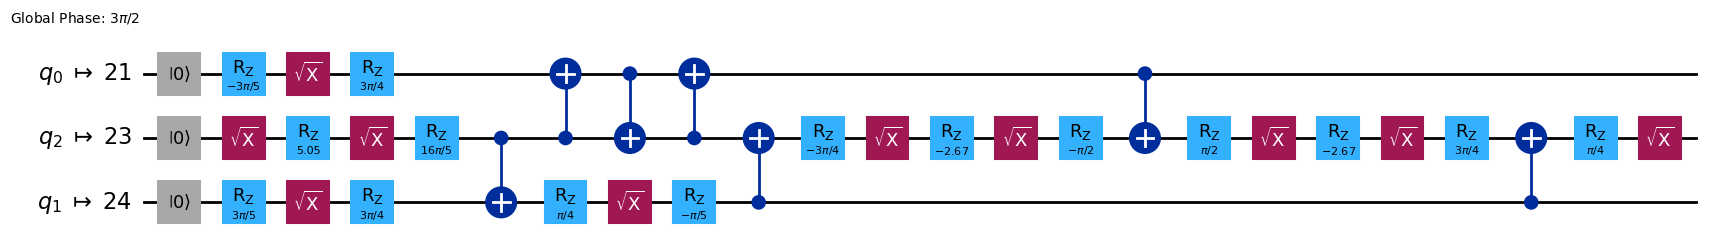

In [18]:
from qiskit import QuantumCircuit
from qiskit import transpile
import numpy as np
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
 
# Get a fake backend from the fake provider
backend = FakeKolkataV2()

lambda0 = 1/np.sqrt(3)
lambda1 = 1/np.sqrt(3)
lambda2 = 1/np.sqrt(3)
phi = np.pi / 5
qc = QuantumCircuit(3)
statevector = np.array([lambda0, 0, 0, 0, lambda1 * np.exp(1j*phi), 0, 0, lambda2], dtype=complex)
qc.initialize(statevector, [0, 1, 2])
qc_transpile = transpile(qc, backend, optimization_level=3)
qc_transpile.draw("mpl")

In [17]:
from qiskit import QuantumCircuit
import numpy as np
from math import atan2, acos, sqrt

def prepare_state(lambda0: float, lambda1: float, lambda2: float, phi: float) -> QuantumCircuit:
    """
    Prepares the state: 
        λ₀ |000⟩ + λ₁ e^{iφ} |100⟩ + λ₂ |111⟩
    Correct version - only 1 CNOT.
    """
    # Normalize
    norm = sqrt(lambda0**2 + lambda1**2 + lambda2**2)
    if norm < 1e-12:
        raise ValueError("Amplitudes sum to zero")
    
    l0 = lambda0 / norm
    l1 = lambda1 / norm
    l2 = lambda2 / norm
    
    # Compute angles
    p0 = l0**2 + l1**2                                 # prob q0 = |0>
    theta0 = 2 * acos(sqrt(p0)) if p0 > 1e-12 else np.pi
    theta2 = 2 * atan2(l1, l0) if l0 > 1e-12 else np.pi   # ratio l1/l0 when q0=0
    theta1 = 2 * atan2(l2, sqrt(p0)) if p0 > 1e-12 else np.pi  # ratio l2 / sqrt(l0²+l1²)
    
    qc = QuantumCircuit(3)
    
    # Step 1: Create superposition on q0 and q2
    qc.ry(theta0, 0)   # controls amplitude between |0xx> and |1xx>
    qc.ry(theta2, 2)   # creates |00> and |10> components when q0=0
    
    # Step 2: CNOT to convert |x01> → |x11>
    qc.cx(0, 2)        # control = q0, target = q2
    
    # Step 3: Adjust amplitude ratio in the |1xx> subspace
    qc.ry(theta1, 0)
    
    # Step 4: Add relative phase only to |100>
    qc.rz(phi, 2)
    
    return qc


# ====================== Test the circuit ======================
if __name__ == "__main__":
    qc = prepare_state(lambda0=0.7, lambda1=0.4, lambda2=0.5916, phi=np.pi/4)
    
    print("Corrected Circuit:")
    print(qc.draw('text'))
    
    # Verify the state
    from qiskit.quantum_info import Statevector
    state = Statevector.from_instruction(qc)
    
    print("\nProbabilities:")
    probs = np.abs(state.data)**2
    print(f"|000⟩ : {probs[0]:.6f}")
    print(f"|001⟩ : {probs[1]:.6f}")   # Should be ~0
    print(f"|100⟩ : {probs[4]:.6f}")
    print(f"|111⟩ : {probs[7]:.6f}")
    
    print("\nAmplitudes (rounded):")
    print(np.round(state.data, decimals=6))

Corrected Circuit:
     ┌────────────┐     ┌────────────┐
q_0: ┤ Ry(1.2661) ├──■──┤ Ry(1.2661) ├
     └────────────┘  │  └────────────┘
q_1: ────────────────┼────────────────
     ┌────────────┐┌─┴─┐ ┌─────────┐  
q_2: ┤ Ry(1.0383) ├┤ X ├─┤ Rz(π/4) ├──
     └────────────┘└───┘ └─────────┘  

Probabilities:
|000⟩ : 0.152660
|001⟩ : 0.423497
|100⟩ : 0.000346
|111⟩ : 0.000000

Amplitudes (rounded):
[0.360976-0.149521j 0.60123 -0.249037j 0.      +0.j
 0.      +0.j       0.017197+0.007123j 0.60123 +0.249037j
 0.      +0.j       0.      +0.j      ]
